# Visualize Pre-Computed Global Front Results

This notebook loads pre-computed front properties from `process_global_fronts.py` and creates visualizations.

**Prerequisites:**
- Run `process_global_fronts.py` first to generate results
- Have the labeled array, properties files, and original data available

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
import xarray as xr
import pandas as pd
from pathlib import Path
import json
from scipy.stats import gaussian_kde

# Cartopy gives correct geographic axis labels on curvilinear grids.
# Install with: pip install cartopy
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
    print('cartopy available ✓')
except ImportError:
    HAS_CARTOPY = False
    print('cartopy NOT found – maps will use pcolormesh without coastlines.\n'
          'Install with: pip install cartopy')

plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
%matplotlib inline

print('Imports successful!')

cartopy available ✓
Imports successful!


## 1. Load Pre-Computed Results

**Note:** If you processed with `--downsample`, this cell will automatically apply the same downsampling to coordinates and divb2 to match the labeled array.

In [6]:
# === RUN SELECTION ===
import os
from pathlib import Path
from fronts.llc import io as llc_io
from fronts.finding import io as finding_io
from fronts.properties import run as prun
from fronts.properties.io import get_global_front_output_path
from fronts.properties import algorithms as prop_algorithms
from fronts.runs.prototypes.one_full import build_v5

CONFIG    = '../../../fronts/runs/prototypes/one_full/run_v5_100_timesteps.yaml'
TIMESTAMP = '2011-12-04T00_00_00'

cfg    = prun.read_build_config(CONFIG, build_version=build_v5.BUILD_VERSION)
run_id = cfg['run_id']
llc_io.set_fronts_path(os.path.join(os.getenv('OS_OGCM'), 'LLC', 'Fronts'))
llc_io.set_run_layout(cfg['run_dir'], file_tag=run_id)

gradb2_channel = prun.channel_for_root(CONFIG, cfg['gradb2_root'],
                                       depth_suffix=cfg['finding_suffix'])
results_dir = llc_io.fronts_dir(run_id, TIMESTAMP)
divb2_file  = llc_io.derived_filename(TIMESTAMP, gradb2_channel, version=run_id)
binary_file = finding_io.binary_filename(TIMESTAMP, cfg['finding_config'], run_id)
coords_file = os.path.join(os.getenv('OS_OGCM'), 'LLC', 'Fronts', 'coords',
                           'LLC_coords_lat_lon.nc')

# run_tag comes from the binary filename -- the same way step 3 named its output
time_str, run_tag, _ = prop_algorithms._parse_fronts_filename(binary_file)
labeled_file  = get_global_front_output_path(results_dir, time_str, 'label_map', run_tag)
geometry_file = get_global_front_output_path(results_dir, time_str, 'geometry',  run_tag)
print(f"{results_dir}\n  {Path(divb2_file).name}\n  {labeled_file.name}\n  {geometry_file.name}")

# === LOAD ===
labeled_global = np.load(labeled_file)
fronts_binary  = np.load(binary_file)
df_global      = pd.read_parquet(geometry_file)

ds_coords  = xr.open_dataset(coords_file)
lat_global = ds_coords['lat'].values if 'lat' in ds_coords else ds_coords['YC'].values
lon_global = ds_coords['lon'].values if 'lon' in ds_coords else ds_coords['XC'].values
ds_coords.close()

ds_divb2     = xr.open_dataset(divb2_file)
divb2_global = ds_divb2[gradb2_channel].values      # 'gradb2' on SURF, 'gradb2_sfc' on DEPTH
ds_divb2.close()

# === ROLL TO -180..+180 ===
shift = -int(np.argmin(lon_global[lon_global.shape[0] // 2, :]))
if shift:
    lon_global, lat_global, labeled_global, divb2_global, fronts_binary = (
        np.roll(a, shift, axis=1) for a in
        (lon_global, lat_global, labeled_global, divb2_global, fronts_binary))

assert labeled_global.shape == lat_global.shape == divb2_global.shape
print(f"✓ {labeled_global.shape}, {len(df_global):,} fronts, {time_str}")

/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V5/SURF/20111204_000000
  LLC4320_2011-12-04T00_00_00_gradb2_v2_2_01.nc
  labeled_fronts_global_20111204T00_00_00_v2_2_01_bfronts.npy
  global_front_geometry_20111204T00_00_00_v2_2_01_bfronts.parquet
✓ (12960, 17280), 133,143 fronts, 2011-12-04T00:00:00


## 2. Select Region for Visualization

Choose one:
- **Option A**: Visualize entire globe (slow rendering)
- **Option B**: Visualize specific lat/lon region (fast)
- **Option C**: Visualize pixel-based region (fast, good for exploration)

In [21]:
# === VISUALIZATION OPTIONS ===

# Option A: Entire globe
VISUALIZE_ENTIRE_GLOBE = False

# Option B: Specific region (lat/lon bounds)
USE_REGION = False
region_bounds = {
    'lat_min': -10,
    'lat_max': 10,
    'lon_min': -180,
    'lon_max': -160
}

# Option C: Pixel region (center + size)
USE_PIXEL_REGION = True
pixel_region = {
    'center_lat': -52.87,
    'center_lon': 14.51,
    'height': 500,
    'width': 500
}

# === EXTRACT REGION ===
if VISUALIZE_ENTIRE_GLOBE:
    print("Visualizing ENTIRE GLOBE...")
    labeled_viz = labeled_global
    lat_viz = lat_global
    lon_viz = lon_global
    divb2_viz = divb2_global
    i_min, i_max = 0, labeled_global.shape[0]
    j_min, j_max = 0, labeled_global.shape[1]
    
    region_bounds = {
        'lat_min': lat_global.min(),
        'lat_max': lat_global.max(),
        'lon_min': lon_global.min(),
        'lon_max': lon_global.max()
    }

elif USE_REGION:
    print(f"Visualizing region: lat=[{region_bounds['lat_min']}, {region_bounds['lat_max']}], "
          f"lon=[{region_bounds['lon_min']}, {region_bounds['lon_max']}]")
    
    lat_mask = (lat_global >= region_bounds['lat_min']) & (lat_global <= region_bounds['lat_max'])
    lon_mask = (lon_global >= region_bounds['lon_min']) & (lon_global <= region_bounds['lon_max'])
    region_mask = lat_mask & lon_mask
    
    rows, cols = np.where(region_mask)
    i_min, i_max = rows.min(), rows.max() + 1
    j_min, j_max = cols.min(), cols.max() + 1
    
    labeled_viz = labeled_global[i_min:i_max, j_min:j_max]
    lat_viz = lat_global[i_min:i_max, j_min:j_max]
    lon_viz = lon_global[i_min:i_max, j_min:j_max]
    divb2_viz = divb2_global[i_min:i_max, j_min:j_max]

elif USE_PIXEL_REGION:
    print(f"Visualizing pixel region: center=({pixel_region['center_lat']:.1f}, {pixel_region['center_lon']:.1f}), "
          f"size={pixel_region['height']}x{pixel_region['width']} pixels")
    
    # Find center pixel
    center_dist = np.sqrt((lat_global - pixel_region['center_lat'])**2 + 
                          (lon_global - pixel_region['center_lon'])**2)
    center_i, center_j = np.unravel_index(np.argmin(center_dist), center_dist.shape)
    
    # Calculate bounds
    half_height = pixel_region['height'] // 2
    half_width = pixel_region['width'] // 2
    
    i_min = max(0, center_i - half_height)
    i_max = min(labeled_global.shape[0], center_i + half_height)
    j_min = max(0, center_j - half_width)
    j_max = min(labeled_global.shape[1], center_j + half_width)
    
    labeled_viz = labeled_global[i_min:i_max, j_min:j_max]
    lat_viz = lat_global[i_min:i_max, j_min:j_max]
    lon_viz = lon_global[i_min:i_max, j_min:j_max]
    divb2_viz = divb2_global[i_min:i_max, j_min:j_max]
    
    region_bounds = {
        'lat_min': lat_viz.min(),
        'lat_max': lat_viz.max(),
        'lon_min': lon_viz.min(),
        'lon_max': lon_viz.max()
    }
    
    print(f"  Actual bounds: lat=[{region_bounds['lat_min']:.2f}, {region_bounds['lat_max']:.2f}], "
          f"lon=[{region_bounds['lon_min']:.2f}, {region_bounds['lon_max']:.2f}]")

print(f"\nVisualization area: {labeled_viz.shape}")
print(f"Front pixels in view: {np.sum(labeled_viz > 0):,}")

Visualizing pixel region: center=(-52.9, 14.5), size=500x500 pixels
  Actual bounds: lat=[-55.77, -49.81], lon=[9.30, 19.70]

Visualization area: (500, 500)
Front pixels in view: 9,676


## 3. Global Context Map

Show where the selected region is on the whole globe

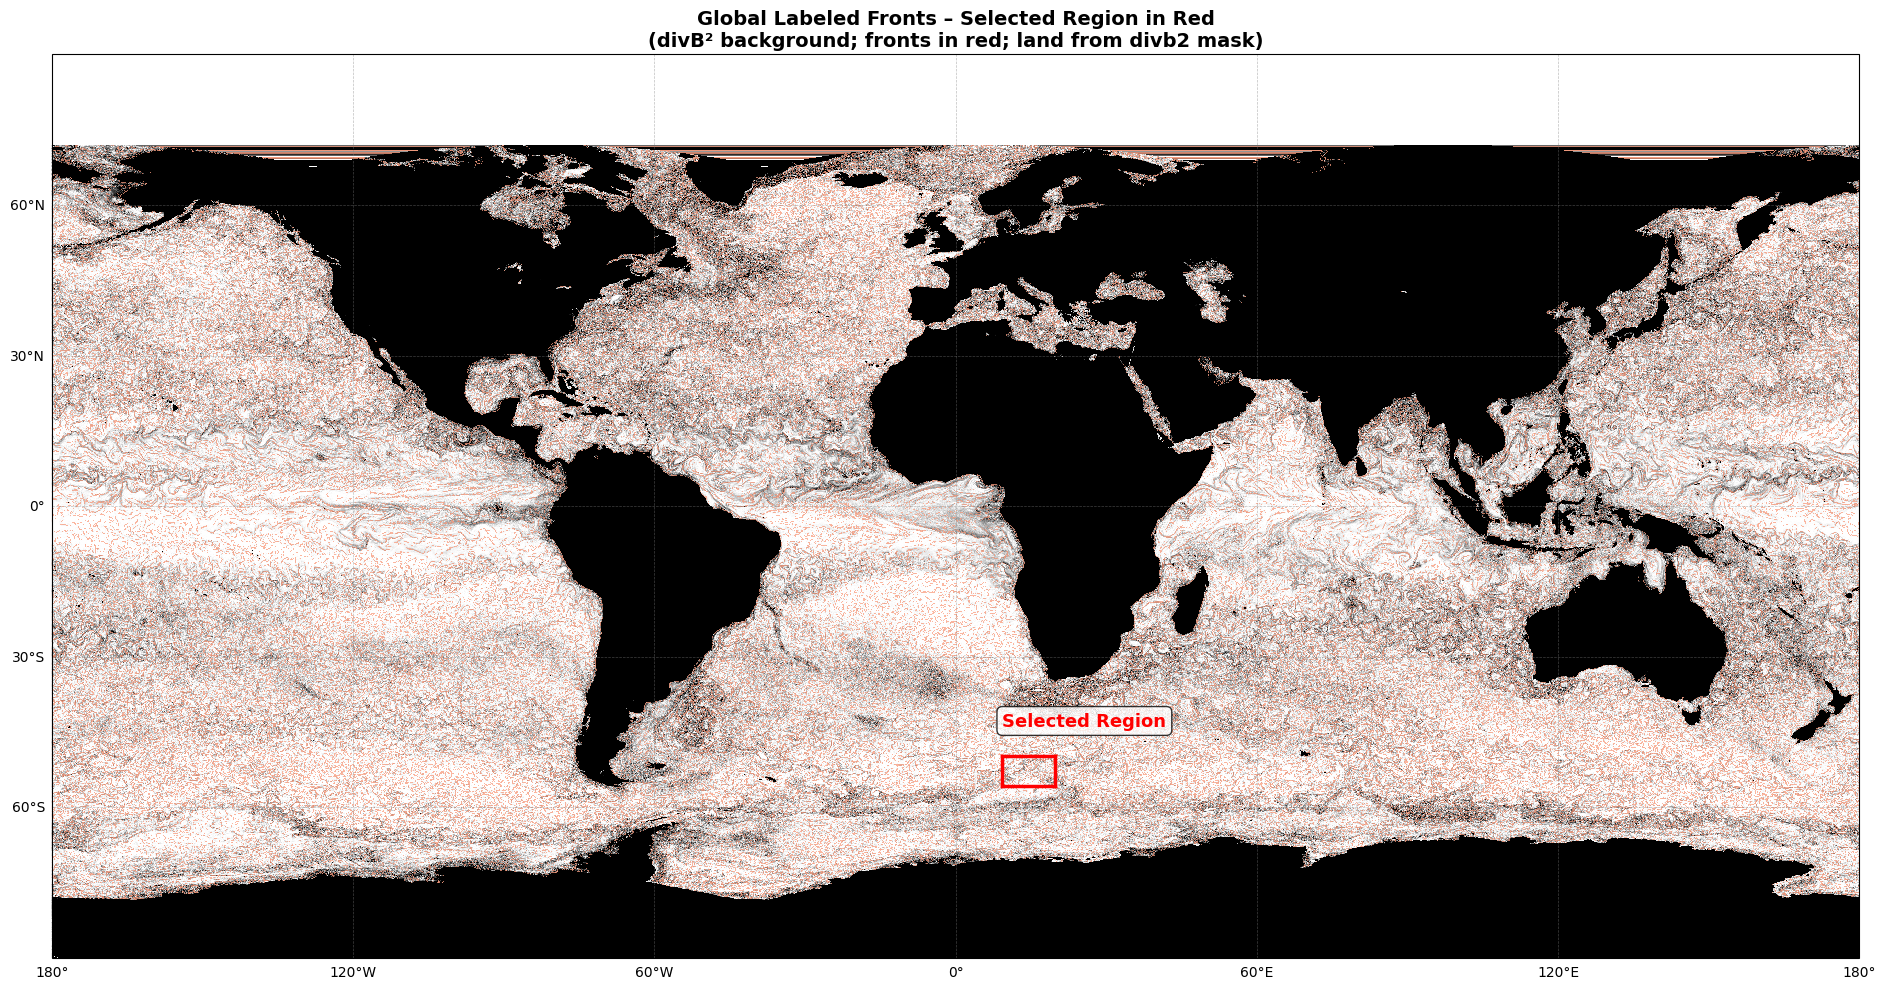

✓ Global context map


In [22]:
# === DISPLAY SETTINGS ===
GLOBAL_DS = 5    # display downsample factor; increase if rendering is slow

ds = GLOBAL_DS
lat_ds = lat_global[::ds, ::ds]
lon_ds = lon_global[::ds, ::ds]

# --- Background: log10(divB²) ---
divb2_ds     = divb2_global[::ds, ::ds]
divb2_log_ds = np.log10(divb2_ds + 1e-15)

# --- Land mask: NaN in divb2 OR non-positive values ---
land_mask_ds = ~np.isfinite(divb2_ds) | (divb2_ds <= 0)
land_ds = land_mask_ds.astype(float)
land_ds[~land_mask_ds] = np.nan          # NaN = ocean (transparent)

# Clip background to ocean-only range for contrast
valid_ocean_ds = np.isfinite(divb2_log_ds) & ~land_mask_ds
if valid_ocean_ds.any():
    vmin_bg = float(np.nanpercentile(divb2_log_ds[valid_ocean_ds],  2))
    vmax_bg = float(np.nanpercentile(divb2_log_ds[valid_ocean_ds], 98))
else:
    vmin_bg, vmax_bg = -20, 0

# --- Front pixels: dilate BEFORE downsampling so 1-px fronts survive ---
# maximum_filter expands each front pixel by ~(ds//2) in each direction,
# ensuring at least ~1 pixel is visible at display resolution.
from scipy.ndimage import maximum_filter
front_binary  = (labeled_global > 0).astype(np.uint8)
front_dilated = maximum_filter(front_binary, size=ds)
front_ds      = front_dilated[::ds, ::ds].astype(float)
front_ds[front_ds == 0] = np.nan         # NaN = background (transparent)

tfm = ccrs.PlateCarree() if HAS_CARTOPY else None

if HAS_CARTOPY:
    fig, ax = plt.subplots(1, 1, figsize=(20, 10),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    pcm_kw = dict(transform=tfm, rasterized=True)

    # 1. divB² background (ocean structure visible)
    ax.pcolormesh(lon_ds, lat_ds, divb2_log_ds,
                  cmap='gray_r', vmin=vmin_bg, vmax=vmax_bg, **pcm_kw)

    # 2. Front pixels (red) -- dilated so they survive downsampling
    ax.pcolormesh(lon_ds, lat_ds, np.ma.masked_invalid(front_ds),
                  cmap='Reds_r', vmin=0, vmax=1.5, alpha=0.75, **pcm_kw)

    # 3. Land mask on top
    ax.pcolormesh(lon_ds, lat_ds, np.ma.masked_invalid(land_ds),
                  cmap='Greys', vmin=0, vmax=1, alpha=1.0, **pcm_kw)

    # True-degree gridlines with axis labels
    gl = ax.gridlines(crs=tfm, draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False
    ax.set_global()
    # Optional -- uncomment once Natural Earth shapefiles are cached:
    # ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k', zorder=4)

else:
    fig, ax = plt.subplots(figsize=(20, 10))
    ax.pcolormesh(lon_ds, lat_ds, divb2_log_ds,
                  cmap='gray_r', vmin=vmin_bg, vmax=vmax_bg, rasterized=True)
    ax.pcolormesh(lon_ds, lat_ds, np.ma.masked_invalid(front_ds),
                  cmap='Reds_r', vmin=0, vmax=1.5, alpha=0.75, rasterized=True)
    ax.pcolormesh(lon_ds, lat_ds, np.ma.masked_invalid(land_ds),
                  cmap='Greys', vmin=0, vmax=1, alpha=1.0, rasterized=True)
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    ax.set_ylabel('Latitude (°N)', fontsize=12)
    ax.grid(True, alpha=0.3)

# Selected-region boundary: trace the ACTUAL curvilinear perimeter
if not VISUALIZE_ENTIRE_GLOBE:
    edges = [
        (lon_global[i_min,    j_min:j_max],  lat_global[i_min,    j_min:j_max]),
        (lon_global[i_max-1,  j_min:j_max],  lat_global[i_max-1,  j_min:j_max]),
        (lon_global[i_min:i_max, j_min],     lat_global[i_min:i_max, j_min]),
        (lon_global[i_min:i_max, j_max-1],   lat_global[i_min:i_max, j_max-1]),
    ]
    plot_kw = dict(color='red', linewidth=2.5, zorder=5)
    if HAS_CARTOPY: plot_kw['transform'] = tfm
    for elon, elat in edges:
        ax.plot(elon, elat, **plot_kw)
    txt_kw = dict(color='red', fontsize=13, fontweight='bold', zorder=6,
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    if HAS_CARTOPY: txt_kw['transform'] = tfm
    ax.text(lon_global[i_min, j_min], lat_global[i_min, j_min] + 12,
            'Selected Region', **txt_kw)

ax.set_title('Global Labeled Fronts – Selected Region in Red\n'
             '(divB² background; fronts in red; land from divb2 mask)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✓ Global context map')


## 4. Map: Before Labeling (Binary Fronts)

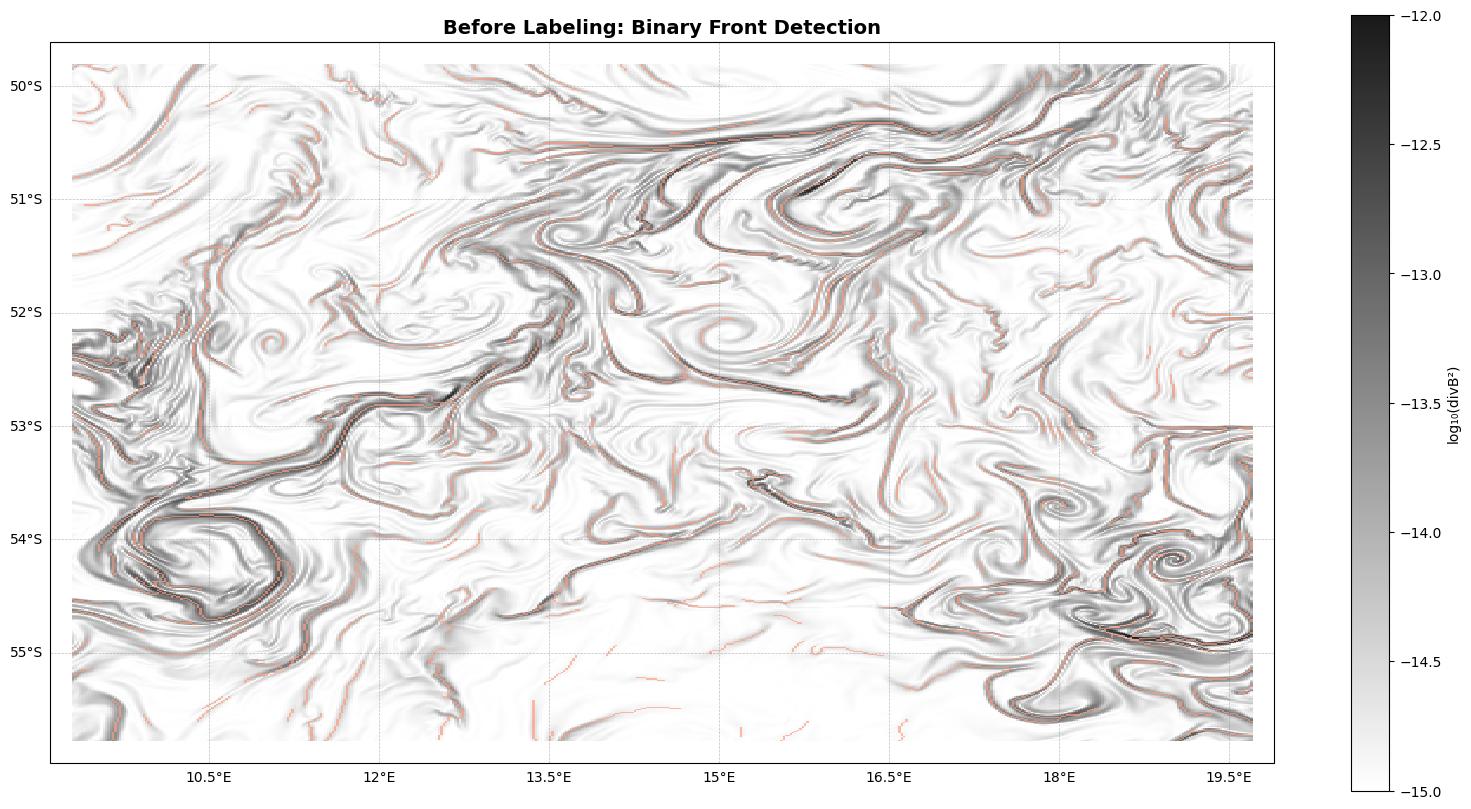

✓ Binary fronts map


In [23]:
tfm = ccrs.PlateCarree() if HAS_CARTOPY else None

# log10(divB²) background
divb2_log = np.log10(divb2_viz + 1e-15)

# Binary front mask (red)
front_bin = (labeled_viz > 0).astype(float)
front_bin[front_bin == 0] = np.nan

# Land mask from divb2
land_viz = (divb2_viz <= 0).astype(float)
land_viz[land_viz == 0] = np.nan

if HAS_CARTOPY:
    fig, ax = plt.subplots(figsize=(16, 10),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([lon_viz.min()-0.2, lon_viz.max()+0.2,
                   lat_viz.min()-0.2, lat_viz.max()+0.2], crs=tfm)
    gl = ax.gridlines(crs=tfm, draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    pcm_kw = dict(transform=tfm, rasterized=True)
else:
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    ax.set_ylabel('Latitude (°N)', fontsize=12)
    ax.grid(True, alpha=0.3, color='white', linewidth=0.5)
    pcm_kw = dict(rasterized=True)

# divB² background
im = ax.pcolormesh(lon_viz, lat_viz, divb2_log,
                   cmap='gray_r', alpha=0.9, **pcm_kw)
plt.colorbar(im, ax=ax, label='log₁₀(divB²)', shrink=0.8)

# Binary fronts (red)
ax.pcolormesh(lon_viz, lat_viz, np.ma.masked_invalid(front_bin),
              cmap='Reds_r', vmin=0, vmax=1.5, alpha=0.7, **pcm_kw)

# Land mask
ax.pcolormesh(lon_viz, lat_viz, np.ma.masked_invalid(land_viz),
              cmap='Greys', vmin=0, vmax=1, alpha=1.0, **pcm_kw)

ax.set_title('Before Labeling: Binary Front Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✓ Binary fronts map')

## 5. Map: After Labeling (Color-Coded Groups)

Rendering 242 color-coded fronts...


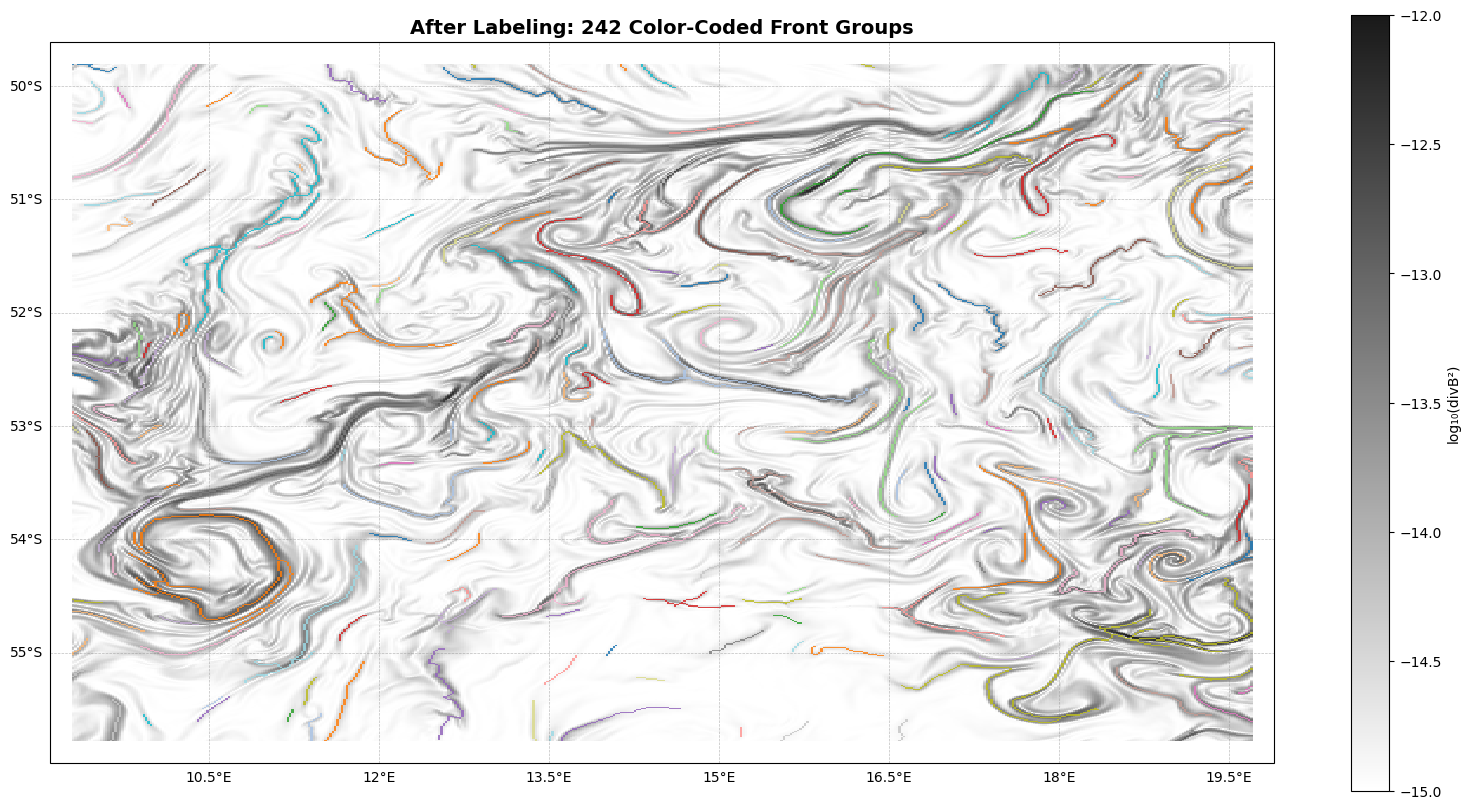

✓ Color-coded fronts map


In [24]:
tfm = ccrs.PlateCarree() if HAS_CARTOPY else None

# log10(divB²) background
divb2_log = np.log10(divb2_viz + 1e-15)

# Assign each front a random [0,1] value for colormap lookup
unique_labels = np.unique(labeled_viz[labeled_viz > 0])
n_fronts = len(unique_labels)
print(f'Rendering {n_fronts:,} color-coded fronts...')

rng_c = np.random.default_rng(42)
lut_c = np.full(int(labeled_viz.max()) + 1, np.nan)
lut_c[unique_labels] = rng_c.random(n_fronts)
front_data = lut_c[labeled_viz].copy()
front_data[labeled_viz == 0] = np.nan

# Land mask
land_viz = (divb2_viz <= 0).astype(float)
land_viz[land_viz == 0] = np.nan

if HAS_CARTOPY:
    fig, ax = plt.subplots(figsize=(16, 10),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([lon_viz.min()-0.2, lon_viz.max()+0.2,
                   lat_viz.min()-0.2, lat_viz.max()+0.2], crs=tfm)
    gl = ax.gridlines(crs=tfm, draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    pcm_kw = dict(transform=tfm, rasterized=True)
else:
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    ax.set_ylabel('Latitude (°N)', fontsize=12)
    ax.grid(True, alpha=0.3, color='white', linewidth=0.5)
    pcm_kw = dict(rasterized=True)

# divB² background
im = ax.pcolormesh(lon_viz, lat_viz, divb2_log,
                   cmap='gray_r', alpha=0.9, **pcm_kw)
plt.colorbar(im, ax=ax, label='log₁₀(divB²)', shrink=0.8)

# Color-coded fronts
ax.pcolormesh(lon_viz, lat_viz, np.ma.masked_invalid(front_data),
              cmap='tab20', alpha=0.85, **pcm_kw)

# Land mask
ax.pcolormesh(lon_viz, lat_viz, np.ma.masked_invalid(land_viz),
              cmap='Greys', vmin=0, vmax=1, alpha=1.0, **pcm_kw)

ax.set_title(f'After Labeling: {n_fronts:,} Color-Coded Front Groups',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✓ Color-coded fronts map')

## 6. Filter Properties to Selected Region

In [25]:
# Filter dataframe to selected region
df_viz = df_global[
    (df_global['centroid_lat'] >= region_bounds['lat_min']) &
    (df_global['centroid_lat'] <= region_bounds['lat_max']) &
    (df_global['centroid_lon'] >= region_bounds['lon_min']) &
    (df_global['centroid_lon'] <= region_bounds['lon_max'])
]

print(f"Fronts in visualization region: {len(df_viz):,} / {len(df_global):,} total")
print(f"  ({100*len(df_viz)/len(df_global):.1f}% of global fronts)")

display(df_viz.head())

Fronts in visualization region: 227 / 133,143 total
  (0.2% of global fronts)


,label,name,time,npix,y0,y1,x0,x1,centroid_lat,centroid_lon,length_km,orientation,num_branches,lat_min,lat_max,lon_min,lon_max,mean_curvature,curvature_direction
28822,33255,20111204TT000000_54.3S_15.0E,2011-12-04T00:00:00,18,4556,4568,2536,2551,-54.254196,14.966434,25.605701,53.355884,0,-54.334183,-54.206432,14.843750,15.135417,0.021937,-0.021937
28851,33284,20111204TT000000_54.2S_9.7E,2011-12-04T00:00:00,17,4558,4575,2286,2289,-54.218025,9.656251,21.975623,4.223764,0,-54.310982,-54.124962,9.635417,9.677083,0.009081,-0.000010
28893,33326,20111204TT000000_54.2S_17.3E,2011-12-04T00:00:00,9,4560,4569,2653,2657,-54.241295,17.311344,12.787205,16.899601,0,-54.287766,-54.194801,17.281250,17.343750,NaN,NaN
28912,33345,20111204TT000000_54.2S_16.9E,2011-12-04T00:00:00,8,4561,4569,2633,2639,-54.235489,16.914062,12.655576,34.392942,0,-54.276157,-54.194801,16.864584,16.968750,NaN,NaN
28930,33363,20111204TT000000_54.2S_18.8E,2011-12-04T00:00:00,19,4562,4580,2721,2732,-54.160473,18.771381,27.041016,29.845614,0,-54.264542,-54.066685,18.697916,18.906250,0.014654,-0.014654


## 7. Plot PDFs of Geometric Properties

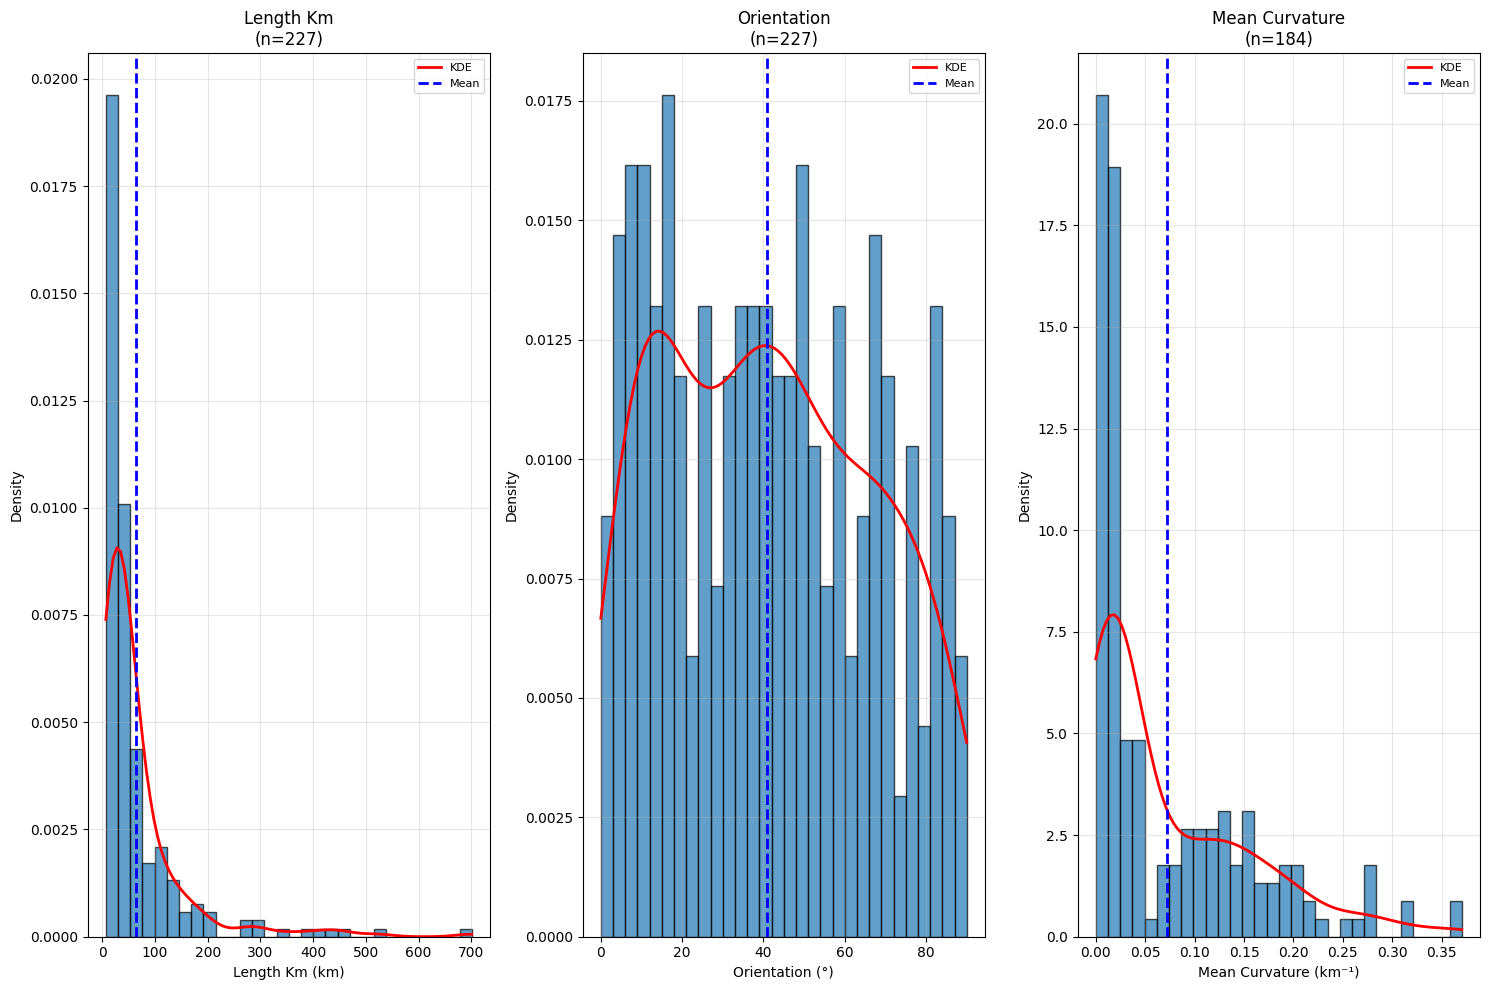

✓ PDFs plotted for 227 fronts


In [26]:
def plot_pdfs(df, properties, ncols=3, figsize=(15, 10)):
    """Plot PDFs for selected properties."""
    nrows = int(np.ceil(len(properties) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
    
    for idx, prop in enumerate(properties):
        ax = axes[idx]
        if prop not in df.columns:
            ax.text(0.5, 0.5, f'{prop}\nnot available', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        if not pd.api.types.is_numeric_dtype(df[prop]):
            ax.text(0.5, 0.5, f'{prop}\n(non-numeric)', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        data = df[prop].dropna()
        if len(data) == 0:
            ax.text(0.5, 0.5, f'{prop}\nno data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        ax.hist(data, bins=30, alpha=0.7, edgecolor='black', density=True)
        
        if len(data) > 10:
            try:
                kde = gaussian_kde(data)
                x_range = np.linspace(data.min(), data.max(), 100)
                ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
            except:
                pass
        
        ax.axvline(data.mean(), color='blue', linestyle='--', linewidth=2, label='Mean')

        # Add units for specific properties
        units_map = {
            'length_km': ' (km)',
            'orientation': ' (°)',
            'mean_curvature': ' (km⁻¹)',
            'curvature_direction': ' (km⁻¹)',
            'lat_range': ' (°)',
            'lon_range': ' (°)'
        }
        units = units_map.get(prop, '')

        ax.set_xlabel(prop.replace('_', ' ').title() + units)
        ax.set_ylabel('Density')
        ax.set_title(f'{prop.replace("_", " ").title()}\n(n={len(data):,})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    for idx in range(len(properties), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    return fig

# Plot geometric properties
geom_to_plot = ['length_km', 'orientation', 'mean_curvature']
fig = plot_pdfs(df_viz, geom_to_plot)
plt.show()

print(f"✓ PDFs plotted for {len(df_viz):,} fronts")

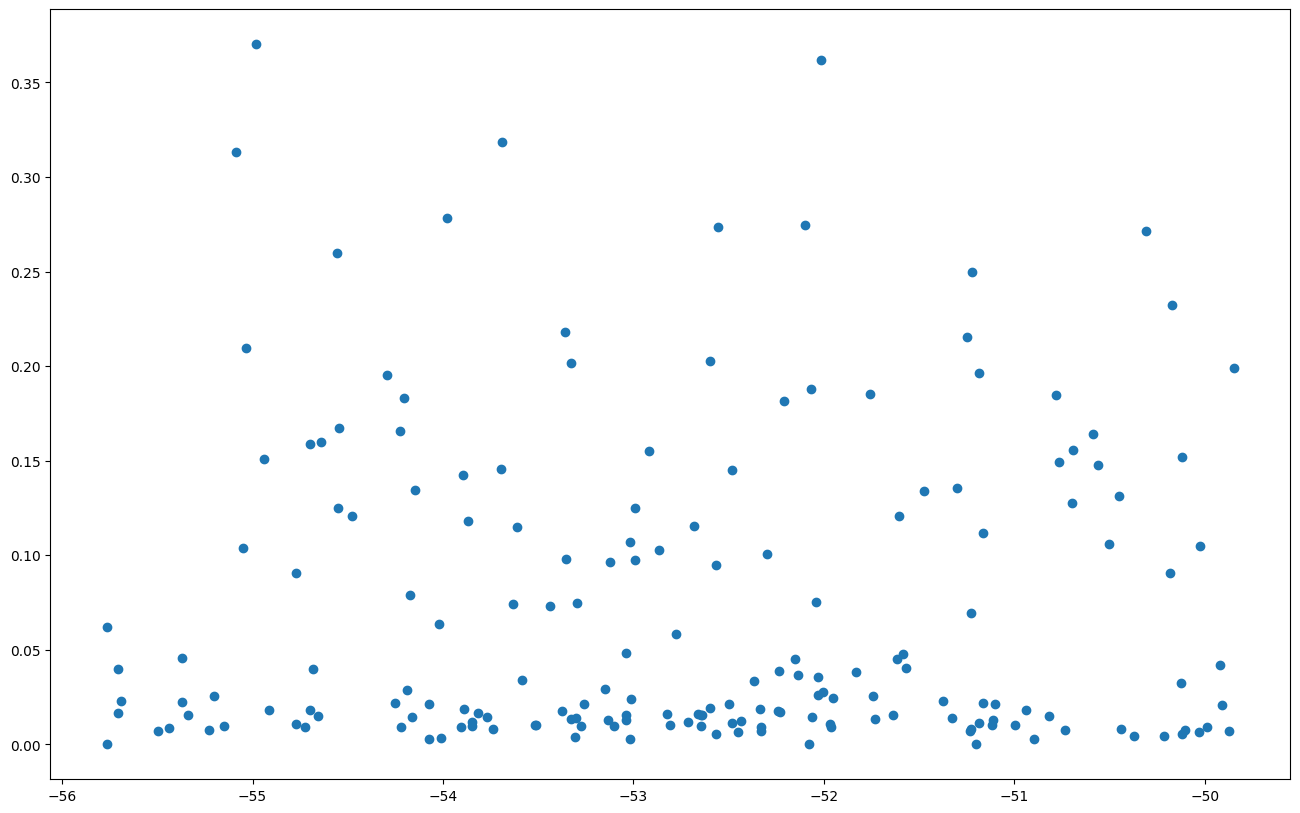

In [27]:


plt.scatter(df_viz['centroid_lat'],df_viz['mean_curvature'])

#plt.scatter(df_viz['centroid_lat'],df_viz['orientation'])

#plt.scatter(df_viz['centroid_lon'],df_viz['length_km'])

## 8. Summary Statistics

In [28]:
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"\nRegion: lat=[{region_bounds['lat_min']:.2f}, {region_bounds['lat_max']:.2f}], "
      f"lon=[{region_bounds['lon_min']:.2f}, {region_bounds['lon_max']:.2f}]")
print(f"\nFronts in region: {len(df_viz):,}")
print(f"Total global fronts: {len(df_global):,}")
print(f"Percentage: {100*len(df_viz)/len(df_global):.2f}%")

print(f"\nGeometric Properties:")
for prop in ['length_km', 'orientation', 'mean_curvature']:
    if prop in df_viz.columns:
        data = df_viz[prop].dropna()
        print(f"  {prop}:")
        print(f"    Mean: {data.mean():.2f}")
        print(f"    Median: {data.median():.2f}")
        print(f"    Std: {data.std():.2f}")
        print(f"    Range: [{data.min():.2f}, {data.max():.2f}]")

print("\n" + "="*70)

SUMMARY STATISTICS

Region: lat=[-55.77, -49.81], lon=[9.30, 19.70]

Fronts in region: 227
Total global fronts: 133,143
Percentage: 0.17%

Geometric Properties:
  length_km:
    Mean: 64.50
    Median: 33.37
    Std: 90.52
    Range: [6.92, 700.82]
  orientation:
    Mean: 40.95
    Median: 39.90
    Std: 25.31
    Range: [0.00, 90.00]
  mean_curvature:
    Mean: 0.07
    Median: 0.03
    Std: 0.08
    Range: [0.00, 0.37]



## 9. Map Fronts Colorcoded by Property

/tmp/ipykernel_3895379/4252436762.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


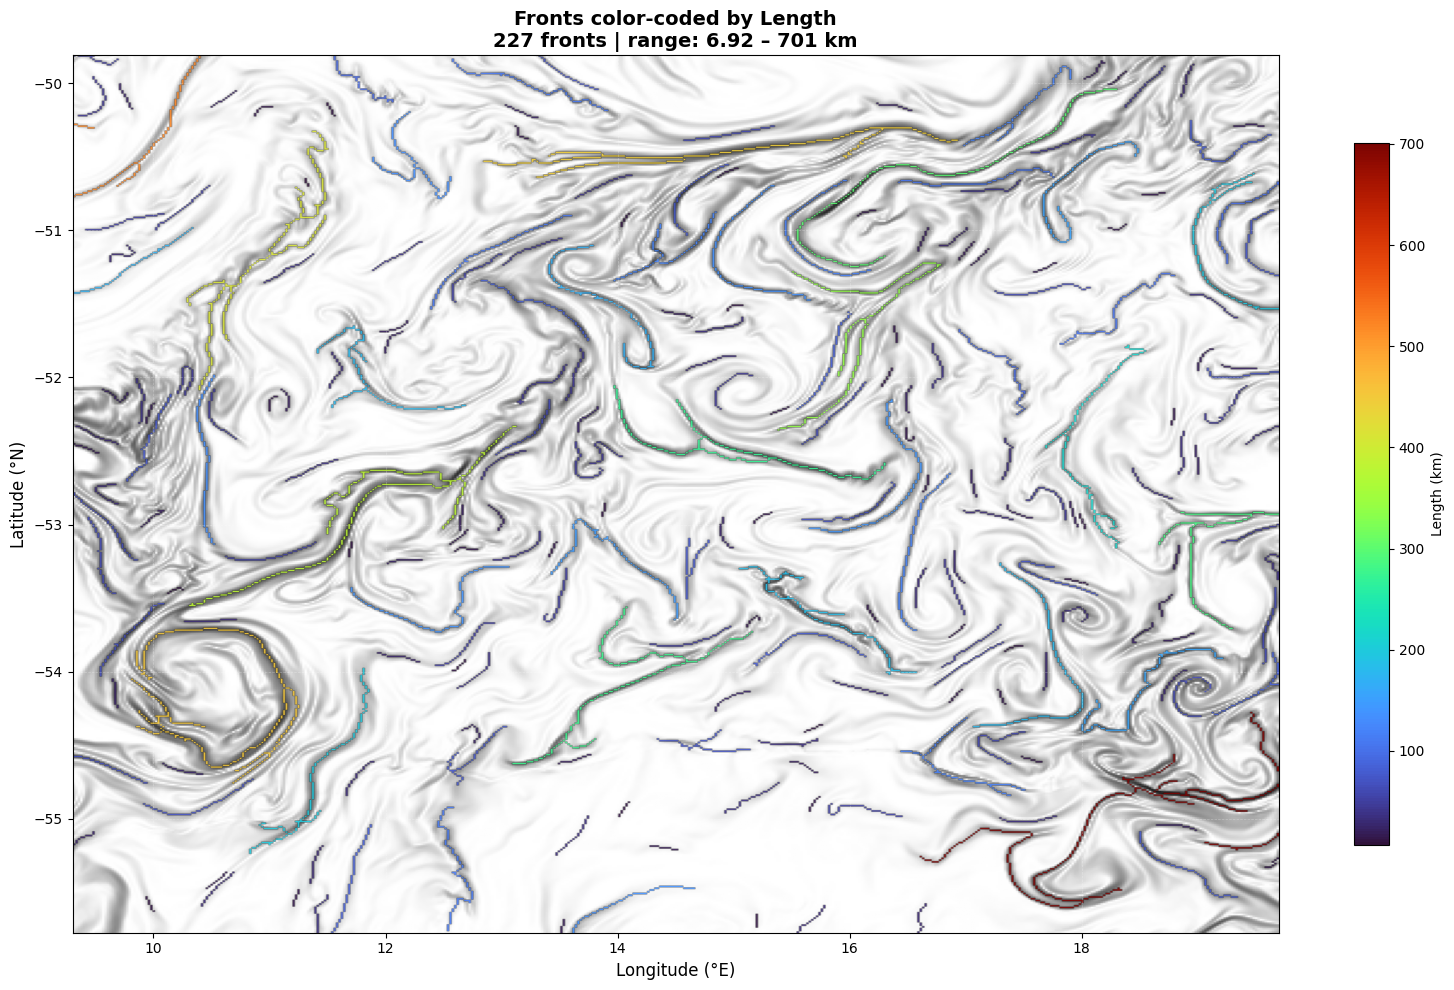

(<Figure size 1600x1000 with 2 Axes>,
 <Axes: title={'center': 'Fronts color-coded by Length\n227 fronts | range: 6.92 – 701 km'}, xlabel='Longitude (°E)', ylabel='Latitude (°N)'>)

In [29]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

def plot_fronts_by_property(
    labeled_viz,
    df_viz,
    lat_viz,
    lon_viz,
    divb2_viz,
    property_name='length_km',       # 'length_km', 'orientation', or 'mean_curvature'
    cmap='plasma',
    alpha=0.9,
):
    """
    Plot fronts color-coded by a single geometric property.

    Parameters
    ----------
    labeled_viz : 2D np.ndarray
        Array of front labels (0 = background, >0 = front label).
    df_viz : pd.DataFrame
        Must contain 'label' and the chosen property column.
        (The region-filtered dataframe from cell 6 of this notebook.)
    lat_viz, lon_viz : 2D np.ndarray
        Coordinate arrays for the visualization region.
    divb2_viz : 2D np.ndarray
        divB² field for the region, used as the background image.
    property_name : str
        Column in df_viz to color by: 'length_km', 'orientation', or 'mean_curvature'.
    cmap : str
        Matplotlib colormap name.
    alpha : float
        Opacity of the front overlay.
    """
    property_labels = {
        'length_km':       ('Length',             'km'),
        'orientation':     ('Orientation',        '°'),
        'mean_curvature':  ('Mean Curvature',     'km⁻¹'),
    }

    if property_name not in df_viz.columns:
        raise ValueError(f"'{property_name}' not found in df_viz. "
                         f"Available: {list(df_viz.columns)}")

    # ------------------------------------------------------------------
    # 1. Build lookup array: front label -> property value
    # ------------------------------------------------------------------
    prop_series = df_viz.set_index('label')[property_name].dropna()

    max_label = int(labeled_viz.max())
    lut = np.full(max_label + 1, np.nan)
    for lbl, val in prop_series.items():
        if lbl <= max_label:
            lut[lbl] = val

    # Map every pixel to its front's property value
    prop_image = lut[labeled_viz]          # shape == labeled_viz.shape
    front_mask = labeled_viz > 0

    # ------------------------------------------------------------------
    # 2. Normalise to [0, 1] for the colormap
    # ------------------------------------------------------------------
    valid = prop_image[front_mask]
    valid = valid[~np.isnan(valid)]
    if len(valid) == 0:
        print(f"⚠️  No valid '{property_name}' values found in this region.")
        return None, None

    vmin, vmax = np.nanmin(valid), np.nanmax(valid)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    colormap = cm.get_cmap(cmap)

    # ------------------------------------------------------------------
    # 3. Build RGBA overlay
    # ------------------------------------------------------------------
    fronts_rgba = np.zeros((*labeled_viz.shape, 4), dtype=float)
    colored_mask = front_mask & ~np.isnan(prop_image)
    fronts_rgba[colored_mask] = colormap(norm(prop_image[colored_mask]))
    fronts_rgba[colored_mask, 3] = alpha

    # ------------------------------------------------------------------
    # 4. Plot
    # ------------------------------------------------------------------
    extent_viz = [lon_viz.min(), lon_viz.max(), lat_viz.min(), lat_viz.max()]

    fig, ax = plt.subplots(figsize=(16, 10))

    # Background: log10(divB²)  — matches cells 4 and 5 of this notebook
    divb2_log = np.log10(divb2_viz + 1e-15)
    im_bg = ax.imshow(divb2_log, extent=extent_viz, origin='lower',
                      aspect='auto', cmap='gray_r', alpha=0.9)

    # Front overlay
    ax.imshow(fronts_rgba, extent=extent_viz, origin='lower', aspect='auto')

    # Colorbar
    label_name, label_units = property_labels.get(
        property_name, (property_name.replace('_', ' ').title(), '')
    )
    sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.8, label=f'{label_name} ({label_units})')

    n_fronts = len(prop_series)
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    ax.set_ylabel('Latitude (°N)', fontsize=12)
    ax.set_title(
        f'Fronts color-coded by {label_name}\n'
        f'{n_fronts:,} fronts | range: {vmin:.3g} – {vmax:.3g} {label_units}',
        fontsize=14, fontweight='bold',
    )
    ax.grid(True, alpha=0.3, linestyle='--', color='white', linewidth=0.5)

    plt.tight_layout()
    plt.show()
    return fig, ax


# ------------------------------------------------------------------
# Usage — pick ONE of the three properties
# ------------------------------------------------------------------
plot_fronts_by_property(labeled_viz, df_viz, lat_viz, lon_viz, divb2_viz,
                        property_name='length_km',cmap='turbo')

#plot_fronts_by_property(labeled_viz, df_viz, lat_viz, lon_viz, divb2_viz,
#                         property_name='orientation', cmap='seismic')

# plot_fronts_by_property(labeled_viz, df_viz, lat_viz, lon_viz, divb2_viz,
#                         property_name='mean_curvature', cmap='viridis')